1. Activation function：Sigmoid() -> GELU。
2. Optimizer -> AdamW + ReduceLROnPlateau。
3. layers 429 → 768 → 256 → 128 → 39。
4. add BatchNorm + Dropout。
5. add weight_decay。
6. add EarlyStopping。
7. add K-Fold Cross Validation。

In [ ]:
### 1. Preparing Data
# Load the training and testing data from the .npy file (NumPy array).
import numpy as np

print('Loading data ...')

data_root='/kaggle/input/nycu-2025-dl-hw-2/timit_11/timit_11/'
train = np.load(data_root + 'train_11.npy')
train_label = np.load(data_root + 'train_label_11.npy')
test = np.load(data_root + 'test_11.npy')

print('Size of training data: {}'.format(train.shape))
print('Size of testing data: {}'.format(test.shape))

Loading data ...
Size of training data: (922449, 429)
Size of testing data: (307483, 429)


In [ ]:
### 2. Create Dataset
import torch
from torch.utils.data import Dataset

class TIMITDataset(Dataset):
    def __init__(self, X, y=None):
        self.data = torch.from_numpy(X).float()
        if y is not None:
            y = y.astype(int)
            self.label = torch.LongTensor(y)
        else:
            self.label = None

    def __getitem__(self, idx):
        if self.label is not None:
            return self.data[idx], self.label[idx]
        else:
            return self.data[idx]

    def __len__(self):
        return len(self.data)

In [ ]:
### 2.1
# Split the labeled data into a training set and a validation set, you can modify the variable VAL_RATIO to change the ratio of validation data.
# 將標記資料拆分為訓練集和驗證集，可以修改變數VAL_RATIO來改變驗證資料的比例。
"""
VAL_RATIO = 0.2  # Adjust parameters 4

percent = int(train.shape[0] * (1 - VAL_RATIO))
train_x, train_y, val_x, val_y = train[:percent], train_label[:percent], train[percent:], train_label[percent:]
print('Size of training set: {}'.format(train_x.shape))
print('Size of validation set: {}'.format(val_x.shape))
"""

"\nVAL_RATIO = 0.2  # Adjust parameters 4\n\npercent = int(train.shape[0] * (1 - VAL_RATIO))\ntrain_x, train_y, val_x, val_y = train[:percent], train_label[:percent], train[percent:], train_label[percent:]\nprint('Size of training set: {}'.format(train_x.shape))\nprint('Size of validation set: {}'.format(val_x.shape))\n"

In [ ]:
### 2.2
# Create a data loader from the dataset, feel free to tweak the variable BATCH_SIZE here.
# 從資料集建立一個資料載入器，可以隨意調整這裡的變數 BATCH_SIZE。
"""
BATCH_SIZE = 256 # Adjust parameters 2

from torch.utils.data import DataLoader

train_set = TIMITDataset(train_x, train_y)
val_set = TIMITDataset(val_x, val_y)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True) #only shuffle the training data
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
"""

'\nBATCH_SIZE = 256 # Adjust parameters 2\n\nfrom torch.utils.data import DataLoader\n\ntrain_set = TIMITDataset(train_x, train_y)\nval_set = TIMITDataset(val_x, val_y)\ntrain_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True) #only shuffle the training data\nval_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)\n'

In [ ]:
### 2.3
# Cleanup the unneeded variables to save memory.
# **notes: if you need to use these variables later, then you may remove this block or clean up unneeded variables later<br>the data size is quite huge, so be aware of memory usage in colab**
# 清理不需要的變數以節省記憶體。
# **注意：如果您稍後需要使用這些變量，則可以刪除此區塊或稍後清理不需要的變數<br>資料量非常大，因此請注意 Colab 中的記憶體使用情況**

import gc

#del train_x, train_y, val_x, val_y  # train, train_label,
gc.collect()  # 回傳釋放的物件數量

41

In [ ]:
### 3. Create Model
# Define model architecture, you are encouraged to change and experiment with the model architecture.
# 定義模型架構，鼓勵您改變和試驗模型架構。
import torch
import torch.nn as nn

class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        self.layer1 = nn.Linear(429, 768)  # learning rate, Adjust parameters 5
        self.bn1 = nn.BatchNorm1d(768)
        self.drop1 = nn.Dropout(0.3)

        self.layer2 = nn.Linear(768, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.drop2 = nn.Dropout(0.2)

        self.layer3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.drop3 = nn.Dropout(0.2)

        self.out = nn.Linear(128, 39)

        #self.act_fn = nn.Sigmoid() # Adjust parameters 6
        self.act_fn = nn.GELU()

    def forward(self, x):
        x = self.layer1(x) # Adjust parameters 7
        x = self.bn1(x)
        x = self.act_fn(x)
        x = self.drop1(x)

        x = self.layer2(x)
        x = self.bn2(x)
        x = self.act_fn(x)
        x = self.drop2(x)

        x = self.layer3(x)
        x = self.bn3(x)
        x = self.act_fn(x)
        x = self.drop3(x)

        x = self.out(x)
        return x

In [ ]:
### 4. Training

#check device
def get_device():
  return 'cuda' if torch.cuda.is_available() else 'cpu'

# st2_2
class EarlyStopping:
    def __init__(self, patience=15, verbose=True, delta=0.0):
        """
        Args:
            patience (int): 沒改善多少 epoch 後停止。
            verbose (bool): 是否顯示提示訊息。
            delta (float): 最小改善幅度。
        """
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_acc):
        score = val_acc
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

In [ ]:
### 4.1
# Fix random seeds for reproducibility.
# 修復隨機種子以實現可重複性。

# fix random seed
def same_seeds(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

In [ ]:
### 4.2
# Feel free to change the training parameters here.
# 請隨意在此處變更訓練參數。

# fix random seed for reproducibility
same_seeds(0)

# KFold
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=0)
BATCH_SIZE = 256

# get device
device = get_device()
print(f'DEVICE: {device}')

# training parameters
num_epoch = 50    # number of training epoch, Adjust parameters 3
learning_rate = 0.0005  # learning rate, Adjust parameters 1

# the path where checkpoint saved
model_path = './model.ckpt'

#optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) # Adjust parameters 8

#st2_2 新增 ReduceLROnPlateau 學習率調整器
from torch.optim.lr_scheduler import ReduceLROnPlateau

DEVICE: cpu



========== Fold 1/5 ==========
Fold 1 | Epoch [001/50] | Train Acc: 0.5811 | Val Acc: 0.6658 | Val Loss: 1.5735 | LR: 0.000500
✅ Fold 1: saving model with acc 0.6658
Fold 1 | Epoch [002/50] | Train Acc: 0.6412 | Val Acc: 0.6894 | Val Loss: 1.5053 | LR: 0.000500
✅ Fold 1: saving model with acc 0.6894
Fold 1 | Epoch [003/50] | Train Acc: 0.6612 | Val Acc: 0.7013 | Val Loss: 1.4679 | LR: 0.000500
✅ Fold 1: saving model with acc 0.7013
Fold 1 | Epoch [004/50] | Train Acc: 0.6739 | Val Acc: 0.7124 | Val Loss: 1.4365 | LR: 0.000500
✅ Fold 1: saving model with acc 0.7124
Fold 1 | Epoch [005/50] | Train Acc: 0.6836 | Val Acc: 0.7193 | Val Loss: 1.4187 | LR: 0.000500
✅ Fold 1: saving model with acc 0.7193
Fold 1 | Epoch [006/50] | Train Acc: 0.6906 | Val Acc: 0.7244 | Val Loss: 1.4032 | LR: 0.000500
✅ Fold 1: saving model with acc 0.7244
Fold 1 | Epoch [007/50] | Train Acc: 0.6959 | Val Acc: 0.7291 | Val Loss: 1.3902 | LR: 0.000500
✅ Fold 1: saving model with acc 0.7291
Fold 1 | Epoch [008/50]

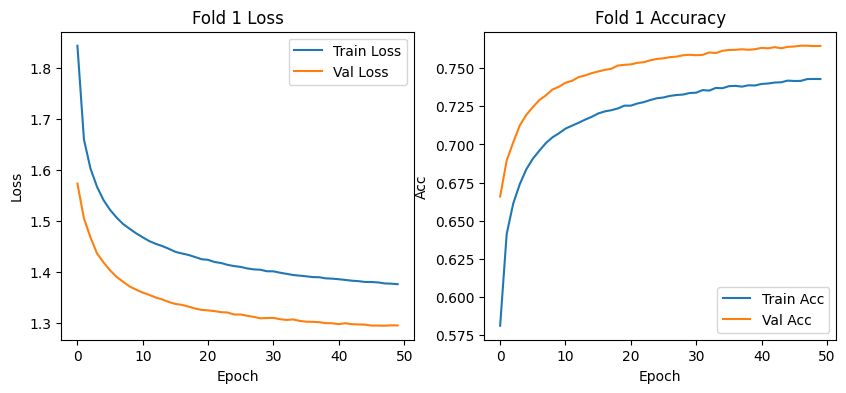


========== Fold 2/5 ==========
Fold 2 | Epoch [001/50] | Train Acc: 0.5813 | Val Acc: 0.6605 | Val Loss: 1.5830 | LR: 0.000500
✅ Fold 2: saving model with acc 0.6605
Fold 2 | Epoch [002/50] | Train Acc: 0.6410 | Val Acc: 0.6858 | Val Loss: 1.5095 | LR: 0.000500
✅ Fold 2: saving model with acc 0.6858
Fold 2 | Epoch [003/50] | Train Acc: 0.6617 | Val Acc: 0.7042 | Val Loss: 1.4636 | LR: 0.000500
✅ Fold 2: saving model with acc 0.7042
Fold 2 | Epoch [004/50] | Train Acc: 0.6756 | Val Acc: 0.7114 | Val Loss: 1.4390 | LR: 0.000500
✅ Fold 2: saving model with acc 0.7114
Fold 2 | Epoch [005/50] | Train Acc: 0.6845 | Val Acc: 0.7179 | Val Loss: 1.4187 | LR: 0.000500
✅ Fold 2: saving model with acc 0.7179
Fold 2 | Epoch [006/50] | Train Acc: 0.6911 | Val Acc: 0.7233 | Val Loss: 1.4038 | LR: 0.000500
✅ Fold 2: saving model with acc 0.7233
Fold 2 | Epoch [007/50] | Train Acc: 0.6976 | Val Acc: 0.7287 | Val Loss: 1.3920 | LR: 0.000500
✅ Fold 2: saving model with acc 0.7287
Fold 2 | Epoch [008/50]

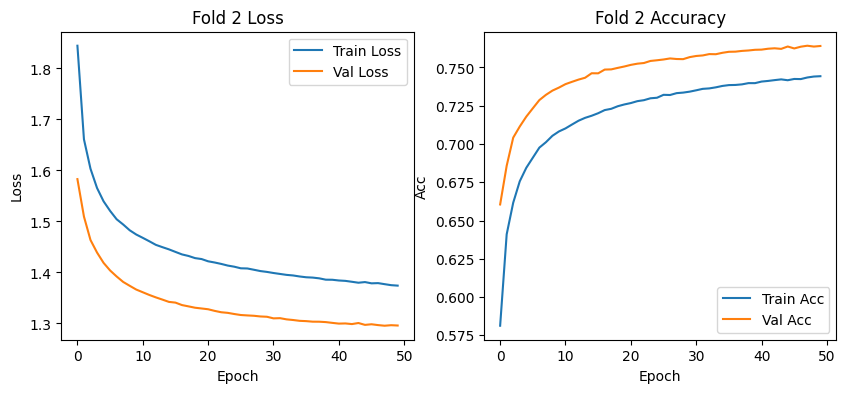


========== Fold 3/5 ==========
Fold 3 | Epoch [001/50] | Train Acc: 0.5815 | Val Acc: 0.6646 | Val Loss: 1.5747 | LR: 0.000500
✅ Fold 3: saving model with acc 0.6646
Fold 3 | Epoch [002/50] | Train Acc: 0.6408 | Val Acc: 0.6882 | Val Loss: 1.5030 | LR: 0.000500
✅ Fold 3: saving model with acc 0.6882
Fold 3 | Epoch [003/50] | Train Acc: 0.6606 | Val Acc: 0.7029 | Val Loss: 1.4606 | LR: 0.000500
✅ Fold 3: saving model with acc 0.7029
Fold 3 | Epoch [004/50] | Train Acc: 0.6737 | Val Acc: 0.7124 | Val Loss: 1.4353 | LR: 0.000500
✅ Fold 3: saving model with acc 0.7124
Fold 3 | Epoch [005/50] | Train Acc: 0.6832 | Val Acc: 0.7198 | Val Loss: 1.4168 | LR: 0.000500
✅ Fold 3: saving model with acc 0.7198
Fold 3 | Epoch [006/50] | Train Acc: 0.6910 | Val Acc: 0.7236 | Val Loss: 1.4003 | LR: 0.000500
✅ Fold 3: saving model with acc 0.7236
Fold 3 | Epoch [007/50] | Train Acc: 0.6966 | Val Acc: 0.7292 | Val Loss: 1.3882 | LR: 0.000500
✅ Fold 3: saving model with acc 0.7292
Fold 3 | Epoch [008/50]

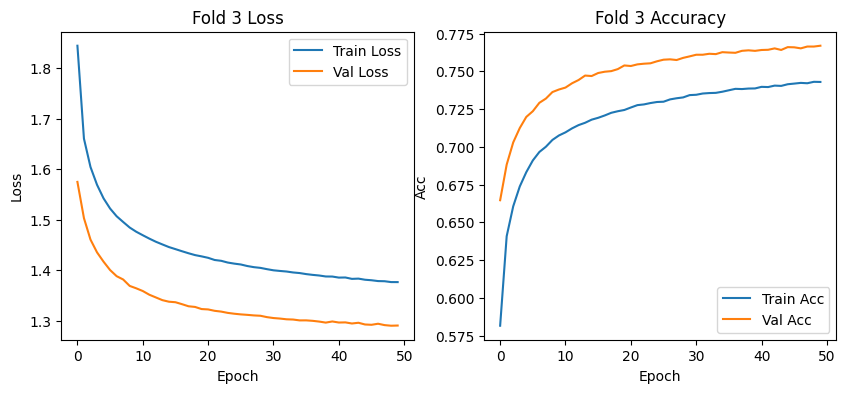


========== Fold 4/5 ==========
Fold 4 | Epoch [001/50] | Train Acc: 0.5811 | Val Acc: 0.6622 | Val Loss: 1.5771 | LR: 0.000500
✅ Fold 4: saving model with acc 0.6622
Fold 4 | Epoch [002/50] | Train Acc: 0.6409 | Val Acc: 0.6886 | Val Loss: 1.5027 | LR: 0.000500
✅ Fold 4: saving model with acc 0.6886
Fold 4 | Epoch [003/50] | Train Acc: 0.6609 | Val Acc: 0.7021 | Val Loss: 1.4631 | LR: 0.000500
✅ Fold 4: saving model with acc 0.7021
Fold 4 | Epoch [004/50] | Train Acc: 0.6747 | Val Acc: 0.7117 | Val Loss: 1.4374 | LR: 0.000500
✅ Fold 4: saving model with acc 0.7117
Fold 4 | Epoch [005/50] | Train Acc: 0.6840 | Val Acc: 0.7186 | Val Loss: 1.4181 | LR: 0.000500
✅ Fold 4: saving model with acc 0.7186
Fold 4 | Epoch [006/50] | Train Acc: 0.6907 | Val Acc: 0.7245 | Val Loss: 1.4012 | LR: 0.000500
✅ Fold 4: saving model with acc 0.7245
Fold 4 | Epoch [007/50] | Train Acc: 0.6967 | Val Acc: 0.7287 | Val Loss: 1.3889 | LR: 0.000500
✅ Fold 4: saving model with acc 0.7287
Fold 4 | Epoch [008/50]

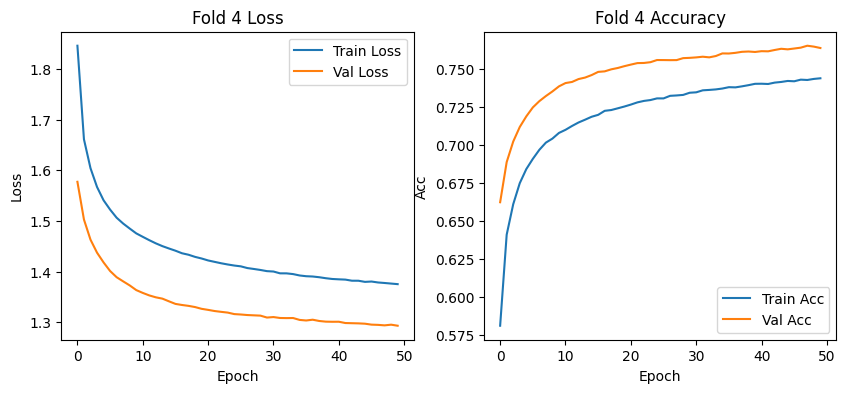


========== Fold 5/5 ==========
Fold 5 | Epoch [001/50] | Train Acc: 0.5812 | Val Acc: 0.6634 | Val Loss: 1.5758 | LR: 0.000500
✅ Fold 5: saving model with acc 0.6634
Fold 5 | Epoch [002/50] | Train Acc: 0.6406 | Val Acc: 0.6877 | Val Loss: 1.5032 | LR: 0.000500
✅ Fold 5: saving model with acc 0.6877
Fold 5 | Epoch [003/50] | Train Acc: 0.6615 | Val Acc: 0.7024 | Val Loss: 1.4643 | LR: 0.000500
✅ Fold 5: saving model with acc 0.7024
Fold 5 | Epoch [004/50] | Train Acc: 0.6754 | Val Acc: 0.7124 | Val Loss: 1.4345 | LR: 0.000500
✅ Fold 5: saving model with acc 0.7124
Fold 5 | Epoch [005/50] | Train Acc: 0.6843 | Val Acc: 0.7181 | Val Loss: 1.4178 | LR: 0.000500
✅ Fold 5: saving model with acc 0.7181
Fold 5 | Epoch [006/50] | Train Acc: 0.6909 | Val Acc: 0.7233 | Val Loss: 1.4033 | LR: 0.000500
✅ Fold 5: saving model with acc 0.7233
Fold 5 | Epoch [007/50] | Train Acc: 0.6963 | Val Acc: 0.7287 | Val Loss: 1.3905 | LR: 0.000500
✅ Fold 5: saving model with acc 0.7287
Fold 5 | Epoch [008/50]

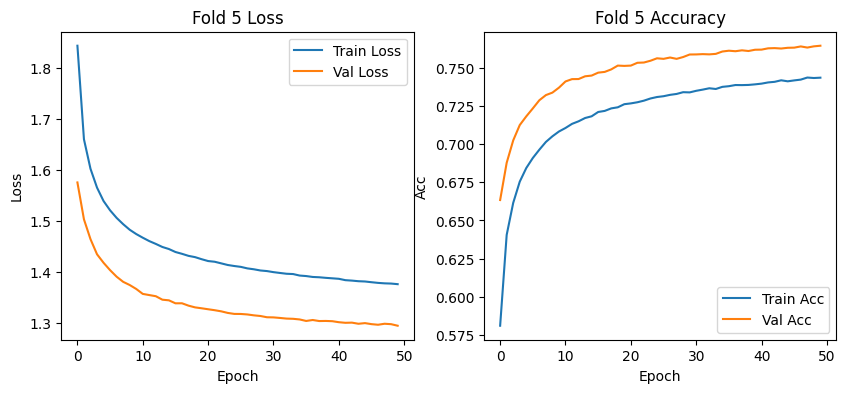


========== Cross Validation Summary ==========
Average Val Acc: 0.7651 ± 0.0010
Average Val Loss: 1.2938 ± 0.0017


In [ ]:
# 4.3 kfold
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 設定 KFold
kf = KFold(n_splits=5, shuffle=True, random_state=0)
BATCH_SIZE = 256

# 用來收集每個 fold 的最佳成績
fold_acc, fold_loss = [], []

# ====== Cross Validation 主迴圈 ======
for fold, (train_idx, val_idx) in enumerate(kf.split(train)):
    print(f"\n========== Fold {fold+1}/5 ==========")
    same_seeds(0)

     # 標準化 (z-score)，使用訓練子集的統計值
    mu = train[train_idx].mean(axis=0, keepdims=True)
    sd = train[train_idx].std(axis=0, keepdims=True) + 1e-8

    X_train = (train[train_idx] - mu) / sd
    X_val   = (train[val_idx]   - mu) / sd

    # 儲存每 fold 的標準化參數，測試時要用
    np.savez_compressed(f'fold{fold+1}_norm.npz', mu=mu, sd=sd)

    # 建立 dataset 與 dataloader
    train_set = TIMITDataset(X_train, train_label[train_idx])
    val_set   = TIMITDataset(X_val,   train_label[val_idx])
    #train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    #val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=(device=='cuda'))
    val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=(device=='cuda'))

    # 初始化模型與訓練參數
    model = Classifier().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=5e-6)
    early_stopping = EarlyStopping(patience=15, verbose=False, delta=1e-4)

    train_acc_list, val_acc_list = [], []
    train_loss_list, val_loss_list = [], []
    best_acc = 0.0
    best_loss = float('inf')

    # ====== 每個 fold 的訓練迴圈 ======
    for epoch in range(num_epoch):
        train_acc, train_loss, val_acc, val_loss = 0.0, 0.0, 0.0, 0.0

        # Training
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, train_pred = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()

            train_acc += (train_pred.cpu() == labels.cpu()).sum().item()
            train_loss += loss.item()

        train_acc /= len(train_set)
        train_loss /= len(train_loader)
        train_acc_list.append(train_acc)
        train_loss_list.append(train_loss)

        # Validation
        model.eval()
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, val_pred = torch.max(outputs, 1)

                val_acc += (val_pred.cpu() == labels.cpu()).sum().item()
                val_loss += loss.item()

        val_acc /= len(val_set)
        val_loss /= len(val_loader)
        val_acc_list.append(val_acc)
        val_loss_list.append(val_loss)
        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Fold {fold+1} | Epoch [{epoch+1:03d}/{num_epoch}] | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | LR: {current_lr:.6f}")

        # 儲存最佳模型
        if val_acc > best_acc:
            best_acc = val_acc
            best_loss = val_loss
            torch.save(model.state_dict(), f'fold{fold+1}_best.ckpt')
            print(f"Fold {fold+1}: saving model with acc {best_acc:.4f}")

        # Early stopping
        early_stopping(val_acc)
        if early_stopping.early_stop:
            print(f"Early stopping on Fold {fold+1}")
            break

    # 避免 GPU 記憶體持續佔用
    del train_set, val_set, train_loader, val_loader
    gc.collect()

    # 儲存每個 fold 的最佳結果
    fold_acc.append(best_acc)
    fold_loss.append(best_loss)

    # 繪圖每個 fold 的訓練曲線
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_loss_list, label='Train Loss')
    plt.plot(val_loss_list, label='Val Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title(f'Fold {fold+1} Loss')

    plt.subplot(1,2,2)
    plt.plot(train_acc_list, label='Train Acc')
    plt.plot(val_acc_list, label='Val Acc')
    plt.xlabel('Epoch'); plt.ylabel('Acc'); plt.legend(); plt.title(f'Fold {fold+1} Accuracy')
    plt.show()

# ====== Cross Validation 結果 ======
print("\n========== Cross Validation Summary ==========")
print(f"Average Val Acc: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Average Val Loss: {np.mean(fold_loss):.4f} ± {np.std(fold_loss):.4f}")

In [ ]:
### 5. Testing
# Create a testing dataset, and load model from the saved checkpoint.
# 建立測試資料集，並從已儲存的檢查點載入模型。

from torch.utils.data import DataLoader

test_set = TIMITDataset(test, None)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=(device=='cuda'))

In [ ]:
### 5.1 Make prediction

# 讀取該 fold 的標準化參數
all_logits = []
for f in range(1, 6):
    print(f"Loading model fold {f} ...")
    model = Classifier().to(device)
    model.load_state_dict(torch.load(f'fold{f}_best.ckpt', map_location=device))
    model.eval()
    z = np.load(f'fold{f}_norm.npz')
    mu, sd = z['mu'], z['sd']
    fold_logits = []
    with torch.no_grad():
        for data in test_loader:
            x = data.numpy()
            x = (x - mu) / sd
            x = torch.from_numpy(x).float().to(device)
            out = model(x)
            fold_logits.append(out.cpu())

    all_logits.append(torch.cat(fold_logits, dim=0))

# 平均 logits → 取 argmax
avg_logits = torch.stack(all_logits, dim=0).mean(dim=0)
test_pred  = avg_logits.argmax(dim=1).numpy()

Loading model fold 1 ...
Loading model fold 2 ...
Loading model fold 3 ...
Loading model fold 4 ...
Loading model fold 5 ...


In [ ]:
### 6. CSV
with open('prediction5.csv', 'w') as f:
    f.write('Id,Class\n')
    for i, y in enumerate(test_pred):
        f.write('{},{}\n'.format(i, y))